# Image Classification Using CNN

In [349]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2  # This is a package for image processing. pip install opencv-python
import os # for grabbing all filenames of a directory

## Grabbing the filenames in each folder
We will be classifying chickens and ducks. Data is from [Kaggle](https://www.kaggle.com/datasets/roudranildas/chicken-images-classification-dataset/data)

In [350]:
path_c_tr = "../data/chicken_duck/chicken-images/data/train"
path_d_tr = "../data/chicken_duck/duck-images/data/train"
# contains all the chicken filenames for training
c_tr_filenames = os.listdir(path_c_tr)
# contains all the duck filenames for training
d_tr_filenames = os.listdir(path_d_tr)

# for testing
path_c_test = "../data/chicken_duck/chicken-images/data/test"
path_d_test = "../data/chicken_duck/duck-images/data/test"
c_test_filenames = os.listdir(path_c_test)
d_test_filenames = os.listdir(path_d_test)

### Take a look


In [351]:
c_tr_filenames[0]

'6LP5PUXH0T0G.jpg'

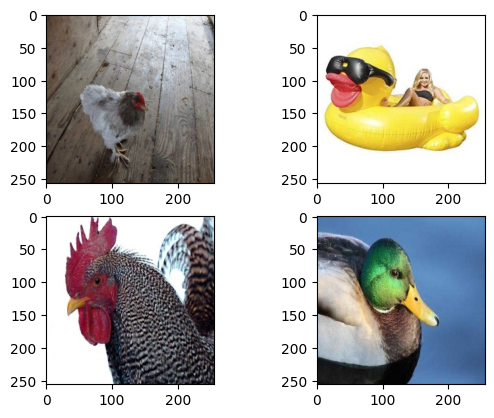

In [352]:
c1 = plt.imread(os.path.join(path_c_tr, c_tr_filenames[0]))
d1 = plt.imread(os.path.join(path_d_tr, d_tr_filenames[0]))
c2 = plt.imread(os.path.join(path_c_test, c_test_filenames[0]))
d2 = plt.imread(os.path.join(path_d_test, d_test_filenames[0]))
fig, axes = plt.subplots(2, 2)
axes[0,0].imshow(c1)
axes[0,1].imshow(d1)
axes[1,0].imshow(c2)
axes[1,1].imshow(d2)
plt.show();

## Create training examples to feed into CNN
- `X_tr` will be a numpy array that stores ALL training images. It is of shape (sample_size, m, n, n_channels)
- `y_tr` will be a 1d numpy array. It is of shape (sample_size,)
    - 1 = chicken
    - 0 = duck

In [353]:
X_tr = []
y_tr = []
m = 64
n = 64
# add chicken images
for p in c_tr_filenames:
    img_array = cv2.imread(os.path.join(path_c_tr, p),cv2.IMREAD_GRAYSCALE)
    new_img_array = cv2.resize(img_array, dsize = (m, n))
    X_tr.append(new_img_array/255) # normalize each image value to [0,1]
    y_tr.append(1)

# add duck images
for p in d_tr_filenames:
    img_array = cv2.imread(os.path.join(path_d_tr, p),cv2.IMREAD_GRAYSCALE)
    new_img_array = cv2.resize(img_array, dsize = (m,n))
    X_tr.append(new_img_array/255) # normalize each image value to [0,1]
    y_tr.append(0)

In [354]:
# in tensorflow, we have to specify channel = 1 for grayscale
X_tr = np.array(X_tr).reshape(-1, m, n, 1)
y_tr = np.array(y_tr)

In [355]:
X_tr.shape

(897, 64, 64, 1)

### Preparing for testing

In [356]:
X_c_test = []
X_d_test = []
for p in c_test_filenames:
    img_array = cv2.imread(os.path.join(path_c_test,p),cv2.IMREAD_GRAYSCALE)
    new_img_array = cv2.resize(img_array, dsize=(m, n))
    X_c_test.append(new_img_array/255)
for p in d_test_filenames:
    img_array = cv2.imread(os.path.join(path_d_test,p),cv2.IMREAD_GRAYSCALE)
    new_img_array = cv2.resize(img_array, dsize=(m, n))
    X_d_test.append(new_img_array/255)
X_c_test = np.array(X_c_test).reshape(-1, m, n, 1)
X_d_test = np.array(X_d_test).reshape(-1, m, n, 1)

## Create a standard CNN model

In [357]:
tf.keras.backend.clear_session()

In [358]:
n1 = 32
n2 = 32
n3 = 32
n4 = 8
batchsize = 16
n_epochs = 25

In [359]:
model_tf1 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = (m, n, 1)), 
    tf.keras.layers.Conv2D(n1, (3,3), activation='relu',),
    tf.keras.layers.MaxPool2D(pool_size=(4,4)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(n2, (3,3), activation='relu',),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(n3, activation='relu', 
                         ),
    tf.keras.layers.Dense(1, activation='sigmoid') 
])

In [360]:
model_tf1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,497 (181.63 KB)

 Trainable params: 46,497 (181.63 KB)

 Non-trainable params: 0 (0.00 B)

In [361]:
tf.keras.utils.set_random_seed(42)
model_tf1.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=['accuracy'],
              )
model_tf1.fit(X_tr, y_tr, epochs = n_epochs, 
              batch_size= batchsize, 
              )

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6856 - loss: 0.6209
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6934 - loss: 0.6018
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6979 - loss: 0.5774
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7213 - loss: 0.5563
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7258 - loss: 0.5360
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7391 - loss: 0.5249
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7369 - loss: 0.5092
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7581 - loss: 0.4972
Epoch 9/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7670 - loss: 0.4802
Epoch 10/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7737 - loss: 0.4692
Epoch 11/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7770 - loss: 0.4549
Epoch 12/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7748 - 

In [362]:
c_prob = model_tf1.predict(X_c_test)
c_class = np.array(c_prob) > 0.5
d_prob = model_tf1.predict(X_d_test)
d_class = np.array(d_prob) > 0.5
print(f"accuracy for classify chickens is: {c_class.mean()}")
print(f"accuracy for classify ducks is: {1-d_class.mean()}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
accuracy for classify chickens is: 0.5523255813953488
accuracy for classify ducks is: 0.8129032258064516


In [363]:
model_tf2 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = (m, n, 1)), 
    tf.keras.layers.SeparableConv2D(n1, (3,3), activation='relu',),
    tf.keras.layers.MaxPool2D(pool_size=(4,4)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.SeparableConv2D(n2, (3,3), activation='relu',),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(n3, activation='relu'),
    #tf.keras.layers.Dense(n4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') 
])

In [364]:
model_tf2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 62, 62, 32)     │            73 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 13, 13, 32)     │         1,344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,346 (149.79 KB)

 Trainable params: 38,346 (149.79 KB)

 Non-trainable params: 0 (0.00 B)

In [365]:
tf.keras.utils.set_random_seed(42)
model_tf2.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=['accuracy'])
model_tf2.fit(X_tr, y_tr, epochs = n_epochs, 
              batch_size = batchsize, 
              )

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6856 - loss: 0.6246
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6934 - loss: 0.6154
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6934 - loss: 0.6133
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6934 - loss: 0.6115
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6934 - loss: 0.6075
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6934 - loss: 0.6045
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6934 - loss: 0.6005
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6934 - loss: 0.5978
Epoch 9/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6934 - loss: 0.5924
Epoch 10/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6957 - loss: 0.5878
Epoch 11/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6934 - loss: 0.5811
Epoch 12/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy:

In [366]:
c_prob = model_tf2.predict(X_c_test)
c_class = np.array(c_prob) > 0.5
d_prob = model_tf2.predict(X_d_test)
d_class = np.array(d_prob) > 0.5
print(f"accuracy for classify chickens is: {c_class.mean()}")
print(f"accuracy for classify ducks is: {1-d_class.mean()}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
accuracy for classify chickens is: 0.46511627906976744
accuracy for classify ducks is: 0.8354838709677419
